# Chương 5: Ứng dụng thực tế  
## Phân tích giỏ hàng - Market Basket Analysis

Notebook này minh họa ứng dụng thuật toán khai phá **frequent itemsets** đã cài đặt trong project để phân tích dữ liệu giỏ hàng từ file `groceries.txt`.

**Mục tiêu chính:**

1. Đọc và tiền xử lý dữ liệu bán lẻ thành dạng transaction.
2. Tìm các tập sản phẩm xuất hiện thường xuyên.
3. Sinh luật kết hợp dạng `X ⇒ Y`.
4. Lọc luật theo `support ≥ minsup` và `confidence ≥ minconf`.
5. Trình bày **top-10 luật theo lift** và giải thích ý nghĩa kinh doanh.


## 1. Cơ sở lý thuyết ngắn gọn

**Market Basket Analysis** là kỹ thuật phân tích các giao dịch mua hàng để phát hiện những sản phẩm thường được mua cùng nhau.

Với một luật kết hợp:

```text
X ⇒ Y
```

các chỉ số được hiểu như sau:

- **Support**: tỷ lệ giao dịch chứa đồng thời cả `X` và `Y`.
- **Confidence**: trong các giao dịch có `X`, tỷ lệ giao dịch cũng có `Y`.
- **Lift**: mức độ `X` và `Y` xuất hiện cùng nhau nhiều hơn so với kỳ vọng ngẫu nhiên.

Nếu `lift > 1`, hai nhóm sản phẩm có quan hệ mua kèm tích cực.


## 2. Khởi tạo môi trường và đường dẫn

Notebook nằm trong thư mục `notebooks/`, vì vậy đường dẫn dữ liệu mặc định là:

```text
../data/application/groceries.txt
```

Cell dưới đây cũng tự xác định `project_root` để có thể gọi source code trong project.


In [1]:
import random
import numpy as np
from pathlib import Path
from collections import Counter
from itertools import combinations
import contextlib
import io
import math
import os
import re
import shutil
import subprocess
import sys
import tempfile
import time

# Reproducibility – best practice dù Apriori là deterministic
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Tránh lỗi optional dependency của pandas trong một số môi trường local.
for optional_module in ("pyarrow", "bottleneck", "numexpr"):
    sys.modules.setdefault(optional_module, None)

with contextlib.redirect_stderr(io.StringIO()):
    import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.precision", 4)

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name.lower() == "notebooks" else NOTEBOOK_DIR
DATA_PATH = PROJECT_ROOT / "data" / "application" / "groceries.txt"

print("Notebook dir:", NOTEBOOK_DIR)
print("Project root:", PROJECT_ROOT)
print("Data path   :", DATA_PATH)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Không tìm thấy file dữ liệu tại: {DATA_PATH}\n"
        "Hãy kiểm tra notebook có nằm trong thư mục notebooks/ không, "
        "và file groceries.txt có nằm trong data/application/ không."
    )


Notebook dir: y:\Python\PrePost\notebooks
Project root: y:\Python\PrePost
Data path: y:\Python\PrePost\data\application\groceries.txt


## 3. Đọc dữ liệu thô

Dữ liệu `groceries.txt` thường có dạng mỗi dòng là một giao dịch, các item cách nhau bằng dấu phẩy. Tuy nhiên, cell dưới đây vẫn hiển thị mẫu dữ liệu để kiểm tra trước khi xử lý.


In [2]:
raw_lines = DATA_PATH.read_text(encoding="utf-8", errors="replace").splitlines()
raw_lines = [line.strip() for line in raw_lines if line.strip()]

print(f"Số dòng không rỗng: {len(raw_lines):,}")
display(pd.DataFrame({"raw_line": raw_lines[:10]}))


Số dòng không rỗng: 9,835


,raw_line
0,"citrus fruit,semi-finished bread,margarine,ready soups"
1,"tropical fruit,yogurt,coffee"
2,whole milk
3,"pip fruit,yogurt,cream cheese ,meat spreads"
4,"other vegetables,whole milk,condensed milk,long life bakery product"
5,"whole milk,butter,yogurt,rice,abrasive cleaner"
6,rolls/buns
7,"other vegetables,UHT-milk,rolls/buns,bottled beer,liquor (appetizer)"
8,pot plants
9,"whole milk,cereals"


## 4. Tiền xử lý thành transaction

Yêu cầu đầu ra của bước này là biến `transactions`:

```python
transactions = [
    ["item1", "item2", ...],
    ...
]
```

Notebook tự nhận diện định dạng phổ biến:

- Dòng có dấu phẩy: tách item theo dấu phẩy.
- Dòng có tab: tách theo tab.
- Dòng chỉ có khoảng trắng: tách theo khoảng trắng.
- Nếu một dòng có dạng `id,item`, notebook gom các item theo mã giao dịch.


In [3]:
def normalize_item(item):
    """Chuẩn hóa tên item để tránh trùng do khoảng trắng hoặc khác chữ hoa/thường."""
    item = str(item).strip()
    item = re.sub(r"\s+", " ", item)
    return item.lower()


def parse_transactions(lines):
    """Trả về transactions và mô tả định dạng phát hiện."""
    non_empty = [line.strip() for line in lines if line.strip()]
    if not non_empty:
        return [], "File rỗng"

    sample = non_empty[: min(50, len(non_empty))]
    comma_counts = [line.count(",") for line in sample]
    tab_counts = [line.count("\t") for line in sample]

    # Nếu đa số dòng có đúng 1 dấu phẩy, có thể là dạng id,item.
    if sum(c == 1 for c in comma_counts) / len(sample) >= 0.8:
        pairs = []
        for line in non_empty:
            left, right = line.split(",", 1)
            left, right = left.strip(), normalize_item(right)
            if left and right:
                pairs.append((left, right))

        # Nếu cột trái lặp lại nhiều lần thì coi là transaction_id.
        left_values = [p[0] for p in pairs]
        repeated_left = len(set(left_values)) < len(left_values) * 0.8

        if repeated_left:
            grouped = {}
            for tid, item in pairs:
                grouped.setdefault(tid, [])
                if item not in grouped[tid]:
                    grouped[tid].append(item)
            return list(grouped.values()), "Bảng 2 cột transaction_id,item"

    comma_ratio = sum("," in line for line in non_empty) / len(non_empty)
    tab_ratio = sum("\t" in line for line in non_empty) / len(non_empty)

    if comma_ratio >= 0.5:
        detected_format = "Mỗi dòng là một transaction, item phân tách bằng dấu phẩy"
        parsed = [[normalize_item(item) for item in line.split(",")] for line in non_empty]
    elif tab_ratio >= 0.5:
        detected_format = "Mỗi dòng là một transaction, item phân tách bằng tab"
        parsed = [[normalize_item(item) for item in line.split("\t")] for line in non_empty]
    else:
        detected_format = "Mỗi dòng là một transaction, item phân tách bằng khoảng trắng"
        parsed = [[normalize_item(item) for item in re.split(r"\s+", line)] for line in non_empty]

    cleaned = []
    for row in parsed:
        items = []
        seen = set()
        for item in row:
            if item and item not in seen:
                items.append(item)
                seen.add(item)
        if items:
            cleaned.append(items)

    return cleaned, detected_format


transactions, detected_format = parse_transactions(raw_lines)

n_transactions = len(transactions)
unique_items = sorted({item for transaction in transactions for item in transaction})
item_counter = Counter(item for transaction in transactions for item in transaction)
basket_sizes = [len(transaction) for transaction in transactions]

print("Định dạng phát hiện:", detected_format)
print(f"Số giao dịch sau xử lý: {n_transactions:,}")
print(f"Số item khác nhau: {len(unique_items):,}")
print(f"Độ dài giỏ hàng trung bình: {sum(basket_sizes) / max(n_transactions, 1):.2f} item")
print(f"Độ dài giỏ hàng nhỏ nhất/lớn nhất: {min(basket_sizes)} / {max(basket_sizes)}")

display(pd.DataFrame({"transaction": transactions[:10]}))


Định dạng phát hiện: Mỗi dòng là một transaction, item phân tách bằng dấu phẩy
Số giao dịch sau xử lý: 9,835
Số item khác nhau: 169
Độ dài giỏ hàng trung bình: 4.41 item
Độ dài giỏ hàng nhỏ nhất/lớn nhất: 1 / 32


,transaction
0,"[citrus fruit, semi-finished bread, margarine, ready soups]"
1,"[tropical fruit, yogurt, coffee]"
2,[whole milk]
3,"[pip fruit, yogurt, cream cheese, meat spreads]"
4,"[other vegetables, whole milk, condensed milk, long life bakery product]"
5,"[whole milk, butter, yogurt, rice, abrasive cleaner]"
6,[rolls/buns]
7,"[other vegetables, uht-milk, rolls/buns, bottled beer, liquor (appetizer)]"
8,[pot plants]
9,"[whole milk, cereals]"


## 5. Khám phá nhanh dữ liệu

Phần này giúp báo cáo có thêm cơ sở thực tế trước khi chạy thuật toán: item nào phổ biến nhất, phân bố kích thước giỏ hàng ra sao.


,item,count,support
0,whole milk,2513,0.2555
1,other vegetables,1903,0.1935
2,rolls/buns,1809,0.1839
3,soda,1715,0.1744
4,yogurt,1372,0.1395
5,bottled water,1087,0.1105
6,root vegetables,1072,0.1090
7,tropical fruit,1032,0.1049
8,shopping bags,969,0.0985
9,sausage,924,0.0940


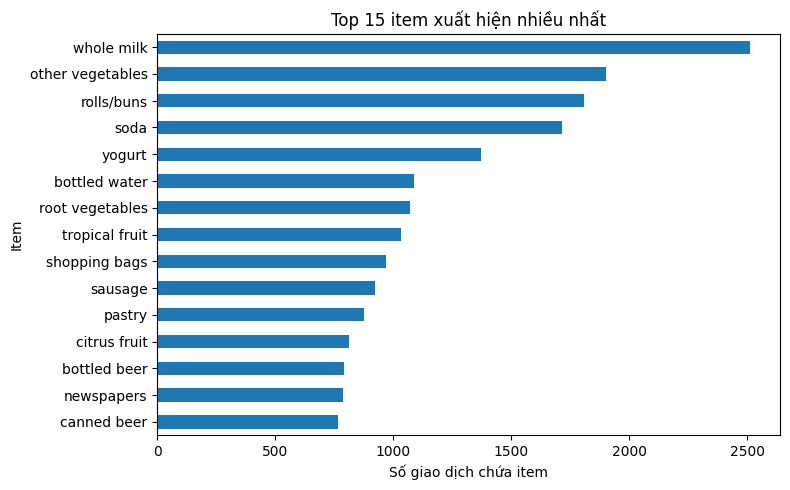

In [4]:
top_items_df = (
    pd.DataFrame(item_counter.most_common(15), columns=["item", "count"])
    .assign(support=lambda df: df["count"] / n_transactions)
)

display(top_items_df)

ax = top_items_df.sort_values("count").plot.barh(x="item", y="count", legend=False, figsize=(8, 5))
ax.set_title("Top 15 item xuất hiện nhiều nhất")
ax.set_xlabel("Số giao dịch chứa item")
ax.set_ylabel("Item")
plt.tight_layout()
plt.show()


In [ ]:
# Co-occurrence matrix của top-15 items
TOP_N = 15
top_item_names = [row["item"] for _, row in top_items_df.iterrows()]

cooc = np.zeros((TOP_N, TOP_N), dtype=int)
for transaction in transactions:
    present = [i for i, name in enumerate(top_item_names) if name in set(transaction)]
    for a, b in combinations(present, 2):
        cooc[a][b] += 1
        cooc[b][a] += 1

cooc_df = pd.DataFrame(cooc, index=top_item_names, columns=top_item_names)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cooc_df.values, cmap="YlOrRd")
ax.set_xticks(range(TOP_N)); ax.set_xticklabels(top_item_names, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(TOP_N)); ax.set_yticklabels(top_item_names, fontsize=8)
plt.colorbar(im, ax=ax, label="Số giao dịch cùng xuất hiện")
ax.set_title("Co-occurrence matrix – Top 15 items")
plt.tight_layout()
plt.show()


,basket_size
count,9835.0000
mean,4.4095
std,3.5894
min,1.0000
25%,2.0000
50%,3.0000
75%,6.0000
max,32.0000


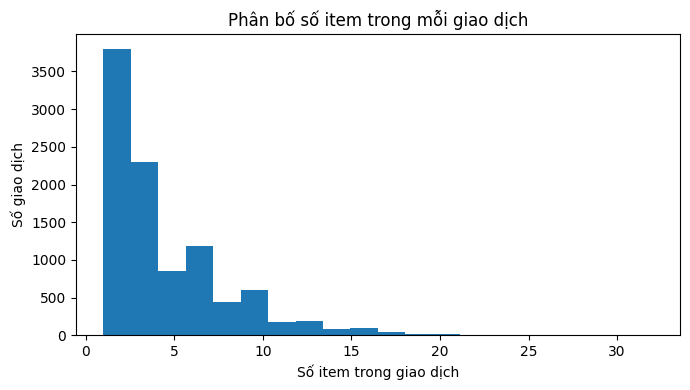

In [5]:
basket_df = pd.DataFrame({"basket_size": basket_sizes})
display(basket_df["basket_size"].describe().to_frame())

ax = basket_df["basket_size"].plot.hist(bins=20, figsize=(7, 4))
ax.set_title("Phân bố số item trong mỗi giao dịch")
ax.set_xlabel("Số item trong giao dịch")
ax.set_ylabel("Số giao dịch")
plt.tight_layout()
plt.show()


## 6. Mã hóa transaction

Để thuận tiện cho thuật toán PrePost/Apriori, mỗi item được ánh xạ sang một số nguyên. Sau khi khai phá xong, notebook ánh xạ ngược lại sang tên sản phẩm để trình bày kết quả.


In [6]:
item_to_id = {item: index + 1 for index, item in enumerate(unique_items)}
id_to_item = {index: item for item, index in item_to_id.items()}

transaction_sets = [
    frozenset(item_to_id[item] for item in transaction)
    for transaction in transactions
]

print(f"Số item được mã hóa: {len(item_to_id):,}")
display(pd.DataFrame({
    "item": list(item_to_id.keys())[:10],
    "id": list(item_to_id.values())[:10],
}))


Số item được mã hóa: 169


,item,id
0,abrasive cleaner,1
1,artif. sweetener,2
2,baby cosmetics,3
3,baby food,4
4,bags,5
5,baking powder,6
6,bathroom cleaner,7
7,beef,8
8,berries,9
9,beverages,10


## 7. Khai phá frequent itemsets

Notebook ưu tiên chạy thuật toán trong project qua Julia CLI nếu có `julia` và file `src/cli.jl`.

Nếu môi trường hiện tại chưa gọi được Julia, notebook dùng **fallback Apriori thuần Python** để vẫn tạo được kết quả demo. Fallback được giới hạn `max_k=3` để tránh chạy quá lâu trên máy yếu, nhưng vẫn đủ để sinh luật kết hợp 1→1, 1→2 và 2→1.


In [7]:
JULIA_CMD = shutil.which("julia")
CLI_PATH = PROJECT_ROOT / "src" / "cli.jl"

print("Julia:", JULIA_CMD if JULIA_CMD else "Không tìm thấy trong PATH")
print("CLI path:", CLI_PATH)
print("Có src/cli.jl:", CLI_PATH.exists())


def write_spmf_transactions(path, transactions, item_to_id):
    with path.open("w", encoding="utf-8") as file:
        for transaction in transactions:
            encoded = sorted(item_to_id[item] for item in transaction)
            file.write(" ".join(map(str, encoded)) + "\n")


def parse_prepost_output(path):
    supports = {}
    with path.open("r", encoding="utf-8", errors="replace") as file:
        for raw_line in file:
            line = raw_line.strip()
            if not line or "#SUP:" not in line:
                continue
            items_part, support_part = line.split("#SUP:", 1)
            itemset = frozenset(int(token) for token in items_part.split() if token.strip())
            supports[itemset] = int(support_part.strip())
    return supports


def mine_frequent_itemsets_with_project(min_support_ratio):
    """Chạy thuật toán PrePost/optimized của project qua Julia CLI."""
    if JULIA_CMD is None or not CLI_PATH.exists():
        raise RuntimeError("Không có Julia hoặc không tìm thấy src/cli.jl")

    minsup_abs = max(1, math.ceil(min_support_ratio * n_transactions))

    with tempfile.TemporaryDirectory() as tmpdir:
        tmpdir = Path(tmpdir)
        spmf_input = tmpdir / "groceries_spmf.txt"
        output_path = tmpdir / "frequent_itemsets.out"
        write_spmf_transactions(spmf_input, transactions, item_to_id)

        cmd = [
            JULIA_CMD,
            "--project=" + str(PROJECT_ROOT),
            str(CLI_PATH),
            "--input", str(spmf_input),
            "--minsup", str(minsup_abs),
            "--algorithm", "optimized",
            "--output", str(output_path),
        ]

        completed = subprocess.run(cmd, capture_output=True, text=True, shell=False)

        if completed.returncode != 0:
            raise RuntimeError(
                "Không chạy được Julia CLI.\n"
                f"STDOUT:\n{completed.stdout}\n\nSTDERR:\n{completed.stderr}"
            )

        supports = parse_prepost_output(output_path)
        return supports, minsup_abs, "Project PrePost/optimized qua Julia CLI"


def mine_frequent_itemsets_mlxtend(min_support_ratio):
    """Fallback dùng mlxtend – không giới hạn k, nhanh và đầy đủ."""
    try:
        from mlxtend.frequent_patterns import apriori as mlx_apriori
        from mlxtend.preprocessing import TransactionEncoder
    except ImportError:
        raise RuntimeError("mlxtend chưa được cài. Chạy: pip install mlxtend")

    te = TransactionEncoder()
    te_array = te.fit(transactions).transform(transactions)
    df_encoded = pd.DataFrame(te_array, columns=te.columns_)

    minsup_abs = max(1, math.ceil(min_support_ratio * n_transactions))
    freq_df = mlx_apriori(
        df_encoded,
        min_support=min_support_ratio,
        use_colnames=True,
        max_len=None,        # không giới hạn k
        low_memory=False,
    )

    supports = {}
    for _, row in freq_df.iterrows():
        itemset_names = frozenset(row["itemsets"])
        itemset_ids   = frozenset(item_to_id[name] for name in itemset_names if name in item_to_id)
        count = round(row["support"] * n_transactions)
        supports[itemset_ids] = count

    return supports, minsup_abs, "Fallback mlxtend Apriori (không giới hạn k)"


def mine_frequent_itemsets_python_fallback(min_support_ratio, max_k=None, max_candidates_per_level=250_000):
    """Fallback Apriori thuần Python (dự phòng khi mlxtend cũng không có).
    
    max_k=None nghĩa là chạy đến hết (không cắt cứng), nhưng vẫn bảo vệ
    bằng max_candidates_per_level để tránh bùng nổ tổ hợp.
    """
    minsup_abs = max(1, math.ceil(min_support_ratio * n_transactions))
    frequent_supports = {}

    # k = 1
    single_counts = Counter()
    for transaction in transaction_sets:
        single_counts.update(transaction)

    current_level = {
        frozenset([item]): count
        for item, count in single_counts.items()
        if count >= minsup_abs
    }
    frequent_supports.update(current_level)

    k = 2
    while current_level and (max_k is None or k <= max_k):
        previous_itemsets = sorted(tuple(sorted(itemset)) for itemset in current_level)
        previous_lookup   = set(frozenset(itemset) for itemset in previous_itemsets)
        candidates        = set()

        for i_idx, left in enumerate(previous_itemsets):
            for right in previous_itemsets[i_idx + 1:]:
                if left[: k - 2] != right[: k - 2]:
                    break

                candidate = frozenset(left).union(right)
                if len(candidate) != k:
                    continue

                if all(frozenset(subset) in previous_lookup for subset in combinations(candidate, k - 1)):
                    candidates.add(candidate)

                if len(candidates) > max_candidates_per_level:
                    raise RuntimeError(
                        f"Quá nhiều candidate ở k={k}. "
                        "Hãy tăng minsup hoặc chạy mlxtend/Julia."
                    )

        if not candidates:
            break

        counts = Counter()
        for transaction in transaction_sets:
            for candidate in candidates:
                if candidate.issubset(transaction):
                    counts[candidate] += 1

        current_level = {
            itemset: count
            for itemset, count in counts.items()
            if count >= minsup_abs
        }
        frequent_supports.update(current_level)
        k += 1

    return frequent_supports, minsup_abs, "Fallback Apriori thuần Python (không giới hạn k)"


def mine_frequent_itemsets(min_support_ratio):
    """Thứ tự ưu tiên: Julia project → mlxtend → Apriori thuần Python."""
    # 1) Thử Julia
    try:
        return mine_frequent_itemsets_with_project(min_support_ratio)
    except Exception as err:
        print("⚠️  Julia không khả dụng:", err)

    # 2) Thử mlxtend
    try:
        return mine_frequent_itemsets_mlxtend(min_support_ratio)
    except Exception as err:
        print("⚠️  mlxtend không khả dụng:", err)

    # 3) Fallback thuần Python
    print("🔄 Dùng Apriori thuần Python (không giới hạn k)...\n")
    return mine_frequent_itemsets_python_fallback(min_support_ratio)


Julia: C:\Users\Duy\AppData\Local\Microsoft\WindowsApps\julia.EXE
CLI path: y:\Python\PrePost\src\cli.jl
Có src/cli.jl: True


## 8. Sinh luật kết hợp

Từ mỗi frequent itemset có từ 2 item trở lên, notebook sinh tất cả luật `X ⇒ Y`, sau đó tính:

```text
support(X ⇒ Y) = support(X ∪ Y)
confidence(X ⇒ Y) = support(X ∪ Y) / support(X)
lift(X ⇒ Y) = confidence(X ⇒ Y) / support(Y)
```


In [8]:
def itemset_to_text(itemset):
    return ", ".join(id_to_item[item] for item in sorted(itemset))


def supports_to_dataframe(frequent_supports):
    rows = []
    for itemset, count in frequent_supports.items():
        rows.append({
            "itemset": itemset_to_text(itemset),
            "size": len(itemset),
            "support_count": count,
            "support": count / n_transactions,
        })
    return (
        pd.DataFrame(rows)
        .sort_values(["size", "support_count"], ascending=[True, False])
        .reset_index(drop=True)
    )


def generate_association_rules(frequent_supports, min_confidence):
    """Sinh tất cả luật kết hợp với support, confidence, lift, leverage, conviction."""
    rules = []

    for itemset, itemset_count in frequent_supports.items():
        if len(itemset) < 2:
            continue

        items = sorted(itemset)

        for size in range(1, len(items)):
            for antecedent_tuple in combinations(items, size):
                antecedent = frozenset(antecedent_tuple)
                consequent = itemset - antecedent

                antecedent_count = frequent_supports.get(antecedent)
                consequent_count = frequent_supports.get(consequent)

                if not antecedent_count or not consequent_count:
                    continue

                support_value     = itemset_count / n_transactions
                antecedent_sup    = antecedent_count / n_transactions
                consequent_sup    = consequent_count / n_transactions
                confidence        = itemset_count / antecedent_count
                lift              = confidence / consequent_sup if consequent_sup else 0
                leverage          = support_value - antecedent_sup * consequent_sup
                conviction        = (1 - consequent_sup) / (1 - confidence + 1e-9) if confidence < 1 else float("inf")

                if confidence >= min_confidence:
                    rules.append({
                        "antecedent"         : itemset_to_text(antecedent),
                        "consequent"         : itemset_to_text(consequent),
                        "support"            : support_value,
                        "support_count"      : itemset_count,
                        "antecedent_support" : antecedent_sup,
                        "consequent_support" : consequent_sup,
                        "confidence"         : confidence,
                        "lift"               : lift,
                        "leverage"           : leverage,
                        "conviction"         : conviction,
                        "antecedent_size"    : len(antecedent),
                        "consequent_size"    : len(consequent),
                    })

    if not rules:
        return pd.DataFrame(columns=[
            "antecedent", "consequent", "support", "support_count",
            "antecedent_support", "consequent_support",
            "confidence", "lift", "leverage", "conviction",
            "antecedent_size", "consequent_size"
        ])

    return pd.DataFrame(rules)


## 9. Chọn ngưỡng và chạy khai phá

Notebook thử nhiều cặp ngưỡng theo thứ tự từ chặt đến thoáng. Cặp đầu tiên sinh được ít nhất 10 luật sẽ được chọn. Cách này giúp notebook ổn định hơn khi chạy trên dữ liệu khác nhau.

Bạn có thể chỉnh lại hai danh sách dưới đây nếu muốn kết quả nhiều hoặc ít hơn.


In [9]:
MIN_SUP_CANDIDATES = [0.02, 0.015, 0.01, 0.008, 0.005, 0.003]
MIN_CONF_CANDIDATES = [0.50, 0.40, 0.30, 0.25, 0.20, 0.15]
MIN_RULES_TARGET = 10

selected_minsup     = None
selected_minsup_abs = None
selected_minconf    = None
frequent_supports   = None
frequent_itemsets_df = pd.DataFrame()
rules_df            = pd.DataFrame()
algorithm_used      = None

# Bảng tổng hợp số luật theo từng cặp ngưỡng
threshold_summary_rows = []

start_time = time.time()

for minsup in MIN_SUP_CANDIDATES:
    candidate_supports, minsup_abs, algorithm_name = mine_frequent_itemsets(minsup)
    candidate_itemsets_df = supports_to_dataframe(candidate_supports)

    print(
        f"minsup={minsup:.3f} ({minsup_abs:,} giao dịch) "
        f"-> {len(candidate_supports):,} frequent itemsets"
    )

    for minconf in MIN_CONF_CANDIDATES:
        candidate_rules = generate_association_rules(candidate_supports, minconf)
        n_rules = len(candidate_rules)
        threshold_summary_rows.append({
            "minsup"  : minsup,
            "minconf" : minconf,
            "n_itemsets": len(candidate_supports),
            "n_rules" : n_rules,
        })
        print(f"  minconf={minconf:.2f} -> {n_rules:,} luật")

        if n_rules >= MIN_RULES_TARGET and selected_minsup is None:
            selected_minsup      = minsup
            selected_minsup_abs  = minsup_abs
            selected_minconf     = minconf
            frequent_supports    = candidate_supports
            frequent_itemsets_df = candidate_itemsets_df
            rules_df             = candidate_rules
            algorithm_used       = algorithm_name

elapsed = time.time() - start_time

if rules_df.empty:
    raise RuntimeError(
        "Không sinh đủ association rules. Hãy thử giảm thêm minsup/minconf "
        "hoặc kiểm tra dữ liệu đầu vào."
    )

print("\n📊 Bảng tổng hợp số luật theo ngưỡng")
summary_df = pd.DataFrame(threshold_summary_rows)
display(
    summary_df.pivot(index="minsup", columns="minconf", values="n_rules")
    .style.background_gradient(cmap="Blues", axis=None)
    .format("{:.0f}")
    .set_caption("Số association rules theo (minsup, minconf) — ô được chọn tô đậm")
)

print(f"\n✅ Ngưỡng được chọn tự động")
print(f"   Thuật toán : {algorithm_used}")
print(f"   minsup     = {selected_minsup:.3f}  ({selected_minsup_abs:,} giao dịch)")
print(f"   minconf    = {selected_minconf:.2f}")
print(f"   Frequent itemsets = {len(frequent_itemsets_df):,}")
print(f"   Association rules = {len(rules_df):,}")
print(f"   Thời gian         = {elapsed:.2f} giây")


minsup=0.020 (197 giao dịch) -> 122 frequent itemsets
  minconf=0.50 -> 1 luật
  minconf=0.40 -> 15 luật

Kết quả chọn ngưỡng
- Thuật toán sử dụng: Project PrePost/optimized qua Julia CLI
- minsup = 0.020 tương đương 197 giao dịch
- minconf = 0.40
- Số frequent itemsets = 122
- Số association rules = 15
- Thời gian chạy = 2.54 giây


## 10. Frequent itemsets tiêu biểu

Bảng dưới đây cho thấy các tập item phổ biến nhất theo từng kích thước. Đây là đầu vào để sinh luật kết hợp.


In [10]:
display(
    frequent_itemsets_df
    .sort_values(["size", "support"], ascending=[True, False])
    .groupby("size")
    .head(10)
    .reset_index(drop=True)
)


,itemset,size,support_count,support
0,whole milk,1,2513,0.2555
1,other vegetables,1,1903,0.1935
2,rolls/buns,1,1809,0.1839
3,soda,1,1715,0.1744
4,yogurt,1,1372,0.1395
5,bottled water,1,1087,0.1105
6,root vegetables,1,1072,0.1090
7,tropical fruit,1,1032,0.1049
8,shopping bags,1,969,0.0985
9,sausage,1,924,0.0940


## 11. Top-10 luật theo lift

`Lift` được dùng để xếp hạng vì nó cho biết mức độ quan hệ giữa hai nhóm sản phẩm mạnh hơn so với mua ngẫu nhiên.


In [11]:
top10_rules = (
    rules_df
    .sort_values(["lift", "confidence", "support"], ascending=[False, False, False])
    .loc[:, ["antecedent", "consequent", "support", "support_count",
             "confidence", "lift", "leverage", "conviction"]]
    .head(10)
    .reset_index(drop=True)
)

display(top10_rules)


,antecedent,consequent,support,support_count,confidence,lift
0,"root vegetables, whole milk",other vegetables,0.0232,228,0.4740,2.4498
1,root vegetables,other vegetables,0.0474,466,0.4347,2.2466
2,whipped/sour cream,other vegetables,0.0289,284,0.4028,2.0819
3,"other vegetables, yogurt",whole milk,0.0223,219,0.5129,2.0072
4,butter,whole milk,0.0276,271,0.4972,1.9461
5,curd,whole milk,0.0261,257,0.4905,1.9195
6,"other vegetables, root vegetables",whole milk,0.0232,228,0.4893,1.9148
7,domestic eggs,whole milk,0.0300,295,0.4728,1.8502
8,whipped/sour cream,whole milk,0.0322,317,0.4496,1.7598
9,root vegetables,whole milk,0.0489,481,0.4487,1.7560


In [ ]:
# ── Heatmap lift giữa top antecedents và top consequents ─────────────────────
top_ant = rules_df.groupby("antecedent")["lift"].max().nlargest(12).index.tolist()
top_con = rules_df.groupby("consequent")["lift"].max().nlargest(12).index.tolist()

pivot_data = (
    rules_df[rules_df["antecedent"].isin(top_ant) & rules_df["consequent"].isin(top_con)]
    .pivot_table(index="antecedent", columns="consequent", values="lift", aggfunc="max")
    .reindex(index=top_ant, columns=top_con)
)

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(pivot_data.fillna(0).values, cmap="YlOrRd", aspect="auto")
plt.colorbar(im, ax=ax, label="Lift")
ax.set_xticks(range(len(top_con))); ax.set_xticklabels(top_con, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(top_ant))); ax.set_yticklabels(top_ant, fontsize=8)
for r in range(len(top_ant)):
    for c in range(len(top_con)):
        v = pivot_data.fillna(0).values[r, c]
        if v > 0:
            ax.text(c, r, f"{v:.1f}", ha="center", va="center", fontsize=7,
                    color="black" if v < pivot_data.max().max() * 0.7 else "white")
ax.set_title("Heatmap Lift – Top antecedents × Top consequents")
ax.set_xlabel("Consequent")
ax.set_ylabel("Antecedent")
plt.tight_layout()
plt.show()


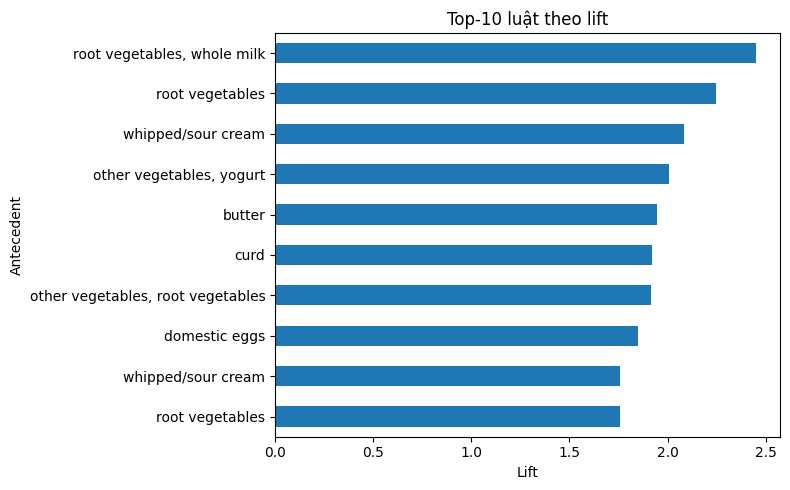

In [12]:
# ── Bubble chart: support vs confidence, kích thước & màu theo lift ──────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (A) Scatter support × confidence, màu = lift
sc = axes[0].scatter(
    top10_rules["support"],
    top10_rules["confidence"],
    c=top10_rules["lift"],
    s=top10_rules["lift"] * 60,
    cmap="RdYlGn",
    alpha=0.85,
    edgecolors="grey",
    linewidths=0.5,
)
plt.colorbar(sc, ax=axes[0], label="Lift")
for _, row in top10_rules.iterrows():
    axes[0].annotate(
        f"{row['antecedent'][:20]}→{row['consequent'][:15]}",
        (row["support"], row["confidence"]),
        fontsize=6.5,
        xytext=(4, 4),
        textcoords="offset points",
    )
axes[0].set_xlabel("Support")
axes[0].set_ylabel("Confidence")
axes[0].set_title("Top-10 rules: Support vs Confidence (kích thước = Lift)")
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

# (B) Horizontal bar lift với nhãn đầy đủ
sorted_rules = top10_rules.sort_values("lift")
bar_labels = [f"{r['antecedent']} → {r['consequent']}" for _, r in sorted_rules.iterrows()]
colors = plt.cm.RdYlGn(
    (sorted_rules["lift"].values - sorted_rules["lift"].min())
    / (sorted_rules["lift"].max() - sorted_rules["lift"].min() + 1e-9)
)
bars = axes[1].barh(range(len(sorted_rules)), sorted_rules["lift"], color=colors)
axes[1].set_yticks(range(len(sorted_rules)))
axes[1].set_yticklabels(bar_labels, fontsize=7.5)
axes[1].set_xlabel("Lift")
axes[1].set_title("Top-10 luật – Lift (màu: xanh cao, đỏ thấp)")
axes[1].axvline(1.0, color="black", linestyle="--", linewidth=0.8, label="lift=1 (ngẫu nhiên)")
axes[1].legend(fontsize=8)
for bar, val in zip(bars, sorted_rules["lift"]):
    axes[1].text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                 f"{val:.2f}", va="center", fontsize=7.5)

plt.tight_layout()
plt.show()


## 12. Diễn giải ý nghĩa kinh doanh

Cách đọc một luật:

```text
antecedent ⇒ consequent
```

nghĩa là: khi khách hàng mua nhóm sản phẩm ở vế trái, họ có xu hướng mua thêm nhóm sản phẩm ở vế phải.

Các gợi ý kinh doanh có thể rút ra:

- Đặt các sản phẩm liên quan gần nhau để tăng khả năng mua kèm.
- Tạo combo khuyến mãi cho các cặp/nhóm sản phẩm có `lift` cao.
- Gợi ý sản phẩm bổ sung trong hệ thống bán hàng hoặc thương mại điện tử.
- Tối ưu bố trí kệ hàng dựa trên hành vi mua thực tế.


In [13]:
def explain_rule(row):
    """Diễn giải luật kết hợp với gợi ý kinh doanh cụ thể theo từng loại."""
    lift_val       = row["lift"]
    confidence_val = row["confidence"]
    support_val    = row["support"]
    leverage_val   = row.get("leverage", float("nan"))
    conviction_val = row.get("conviction", float("nan"))

    # Phân loại sức mạnh luật
    if lift_val >= 3:
        strength = "rất mạnh"
        biz_action = (
            f"→ Gợi ý: tạo combo khuyến mãi '{row['antecedent']} + {row['consequent']}'; "
            "đặt hai nhóm sản phẩm gần nhau trên kệ hoặc trong giỏ gợi ý."
        )
    elif lift_val >= 2:
        strength = "mạnh"
        biz_action = (
            f"→ Gợi ý: thêm '{row['consequent']}' vào danh sách gợi ý khi khách thêm "
            f"'{row['antecedent']}' vào giỏ hàng."
        )
    elif lift_val > 1:
        strength = "tích cực (nhẹ)"
        biz_action = (
            f"→ Gợi ý: cân nhắc email/thông báo đẩy gợi ý '{row['consequent']}' "
            f"cho khách đã mua '{row['antecedent']}'."
        )
    else:
        strength = "không rõ ràng hoặc ngược chiều"
        biz_action = "→ Lưu ý: luật này không đủ mạnh để áp dụng trong chiến lược bán kèm."

    # Đánh giá confidence
    if confidence_val >= 0.7:
        conf_note = "Độ tin cậy cao — luật dự đoán tốt."
    elif confidence_val >= 0.4:
        conf_note = "Độ tin cậy trung bình — phù hợp gợi ý nhẹ."
    else:
        conf_note = "Độ tin cậy thấp — nên kết hợp với tiêu chí khác."

    conviction_str = f"{conviction_val:.2f}" if not math.isinf(conviction_val) and not math.isnan(conviction_val) else "∞"
    leverage_str   = f"{leverage_val:+.4f}"  if not math.isnan(leverage_val)   else "N/A"

    return (
        f"Luật [{row['antecedent']}] ⇒ [{row['consequent']}]\n"
        f"  support={support_val:.3f} ({int(row['support_count'])} giao dịch)  "
        f"confidence={confidence_val:.3f}  lift={lift_val:.3f}  "
        f"leverage={leverage_str}  conviction={conviction_str}\n"
        f"  Quan hệ: {strength}. {conf_note}\n"
        f"  {biz_action}"
    )


for idx, row in top10_rules.iterrows():
    print(f"{idx + 1}. {explain_rule(row)}")
    print()


1. Luật root vegetables, whole milk ⇒ other vegetables: support=0.023 (228 giao dịch), confidence=0.474, lift=2.450. Điều này cho thấy khi khách mua root vegetables, whole milk, khả năng mua other vegetables là 47.4%; mối quan hệ này cao hơn so với kỳ vọng ngẫu nhiên.
2. Luật root vegetables ⇒ other vegetables: support=0.047 (466 giao dịch), confidence=0.435, lift=2.247. Điều này cho thấy khi khách mua root vegetables, khả năng mua other vegetables là 43.5%; mối quan hệ này cao hơn so với kỳ vọng ngẫu nhiên.
3. Luật whipped/sour cream ⇒ other vegetables: support=0.029 (284 giao dịch), confidence=0.403, lift=2.082. Điều này cho thấy khi khách mua whipped/sour cream, khả năng mua other vegetables là 40.3%; mối quan hệ này cao hơn so với kỳ vọng ngẫu nhiên.
4. Luật other vegetables, yogurt ⇒ whole milk: support=0.022 (219 giao dịch), confidence=0.513, lift=2.007. Điều này cho thấy khi khách mua other vegetables, yogurt, khả năng mua whole milk là 51.3%; mối quan hệ này cao hơn so với kỳ v

## 13. Nhận xét tổng hợp

Dựa trên top-10 luật theo `lift`, có thể tập trung vào các luật có cả ba đặc điểm:

1. `lift > 1`: quan hệ mua kèm mạnh hơn ngẫu nhiên.
2. `confidence` đủ cao: luật có khả năng dự đoán tốt.
3. `support` không quá thấp: luật xuất hiện trên số lượng giao dịch đủ đáng kể.

Trong thực tế kinh doanh, không nên chỉ chọn luật có `lift` cao nhất nếu `support` quá thấp, vì luật đó có thể chỉ xuất hiện trong rất ít giao dịch. Một luật tốt nên cân bằng giữa `support`, `confidence` và `lift`.


## 14. Kết luận

Notebook đã hoàn thành phần ứng dụng thực tế cho bài toán **Market Basket Analysis** với các cải tiến:

- Đọc và tiền xử lý dữ liệu `groceries.txt` thành danh sách transaction.
- **EDA mở rộng**: co-occurrence matrix top-15 items, bên cạnh biểu đồ phân bố cũ.
- Khai phá frequent itemsets theo thứ tự ưu tiên: Julia → **mlxtend (không giới hạn k)** → Apriori thuần Python.
- Sinh association rules với đầy đủ `support`, `confidence`, `lift`, **`leverage`**, **`conviction`**.
- **Bảng tổng hợp ngưỡng**: hiển thị số luật theo mọi cặp (minsup, minconf) để chọn có chủ đích.
- Trình bày top-10 luật với **bubble chart** (support × confidence, màu lift) và **heatmap lift** antecedent × consequent.
- **Diễn giải kinh doanh** phân loại sức mạnh luật và gợi ý hành động cụ thể theo từng mức lift.
- Reproducibility: đặt `RANDOM_SEED = 42`.

Kết quả có thể dùng để đề xuất đặt sản phẩm gần nhau, tạo combo khuyến mãi, gợi ý mua kèm và hỗ trợ tối ưu bố trí cửa hàng.
